In [2]:
# Imports
import tensorflow as tf

import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

# For extracting file
import os
import gzip
import shutil
from pathlib import Path

In [4]:
# Essential functions

for gz_file in Path('../global-datasets/tensorflow-number-datasets').glob('*.gz'):
  output_file = gz_file.with_suffix("")
  # print(gz_file, output_file)

  with gzip.open(gz_file, 'rb') as file_in:
    with open(output_file, 'wb') as file_out:
      shutil.copyfileobj(file_in, file_out)
  
  print("Unzip: ", output_file)

def load_image(file_name):
  with open(file_name, 'rb') as f:
    magic_number = int.from_bytes(f.read(4), "big")
    image_count = int.from_bytes(f.read(4), "big")
    image_row = int.from_bytes(f.read(4), "big")
    image_col = int.from_bytes(f.read(4), "big")
    image_data = f.read()

    image = np.frombuffer(
      image_data, dtype=np.uint8
    ).reshape(
      image_count, image_row, image_col
    )
  
  return image

def load_label(file_name):
  with open(file_name, 'rb') as f:
    magic_number = int.from_bytes(f.read(4), 'big')
    count = int.from_bytes(f.read(4), 'big')
    label_data = f.read(count)
    
    label = np.frombuffer(
      label_data, dtype=np.uint8
    )

  return label

Unzip:  ..\global-datasets\tensorflow-number-datasets\t10k-images-idx3-ubyte
Unzip:  ..\global-datasets\tensorflow-number-datasets\t10k-labels-idx1-ubyte
Unzip:  ..\global-datasets\tensorflow-number-datasets\train-images-idx3-ubyte
Unzip:  ..\global-datasets\tensorflow-number-datasets\train-labels-idx1-ubyte


In [5]:
# x is data/image
# y is label

num_class = 10

x_train = load_image("../global-datasets/tensorflow-number-datasets/train-images-idx3-ubyte")
y_train = load_label("../global-datasets/tensorflow-number-datasets/train-labels-idx1-ubyte")

x_test = load_image("../global-datasets/tensorflow-number-datasets/t10k-images-idx3-ubyte")
y_test = load_label("../global-datasets/tensorflow-number-datasets/t10k-labels-idx1-ubyte")

# Normalization to make the data value between 0 - 1
x_train = x_train.astype("uint8") / 255
x_test = x_test.astype("uint8") / 255

y_train = tf.keras.utils.to_categorical(y_train, num_class)
y_test = tf.keras.utils.to_categorical(y_test, num_class)

In [7]:
# CNN Example

input_shape = (28, 28, 1)

# Create sequential Model (Stacking)
model = tf.keras.Sequential()

# Recevie Input (28 x 28 x 1)
model.add(tf.keras.Input(shape=input_shape))

# Conv 2D
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=(5, 5), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

# นำ layer สุดท้ายมาแผ่
model.add(tf.keras.layers.Flatten())

# Hidden Layer เพื่อทำพยากรณ์ผลลัพธ์
model.add(tf.keras.layers.Dense(200, activation="relu"))

# Dropout: ปิด neuron 25% ระหว่าง training เพื่อป้องกัน overfitting
model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(50, activation="relu"))
model.add(tf.keras.layers.Dense(25, activation="relu"))

# พยากรณ์ผลลัพธ์
model.add(tf.keras.layers.Dense(10, activation="softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       320,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 366,213 (1.40 MB)

 Trainable params: 366,213 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Training
batch_size = 10000
epoch = 10

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

history = model.fit(
  x_train,
  y_train,
  batch_size = batch_size,
  epochs = epoch,
  validation_split = 0.2
  # validation_data = (x_test, y_test)
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.1472 - loss: 2.2396 - val_accuracy: 0.2585 - val_loss: 2.0285
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3295 - loss: 1.8850 - val_accuracy: 0.5839 - val_loss: 1.4178
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5548 - loss: 1.3430 - val_accuracy: 0.6698 - val_loss: 0.8838
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6666 - loss: 0.9411 - val_accuracy: 0.8403 - val_loss: 0.6014
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7964 - loss: 0.7015 - val_accuracy: 0.8753 - val_loss: 0.4625
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.8446 - loss: 0.5492 - val_accuracy: 0.8965 - val_loss: 0.3624
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8736 - loss: 0.4344 - val_accuracy: 0.9178 - val_loss: 0.2921
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.8942 - loss: 0.3536 - val_accuracy: 0.9308 - val_loss: 0.2377
Epoch 9/10
5/5

In [9]:
model.save("test1.keras")

In [10]:
_model = tf.keras.models.load_model("test1.keras")

In [11]:
_model.evaluate(
  x_test, y_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9494 - loss: 0.1732


[0.17322975397109985, 0.949400007724762]

In [12]:
result = _model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [13]:
x_test.shape

(10000, 28, 28)

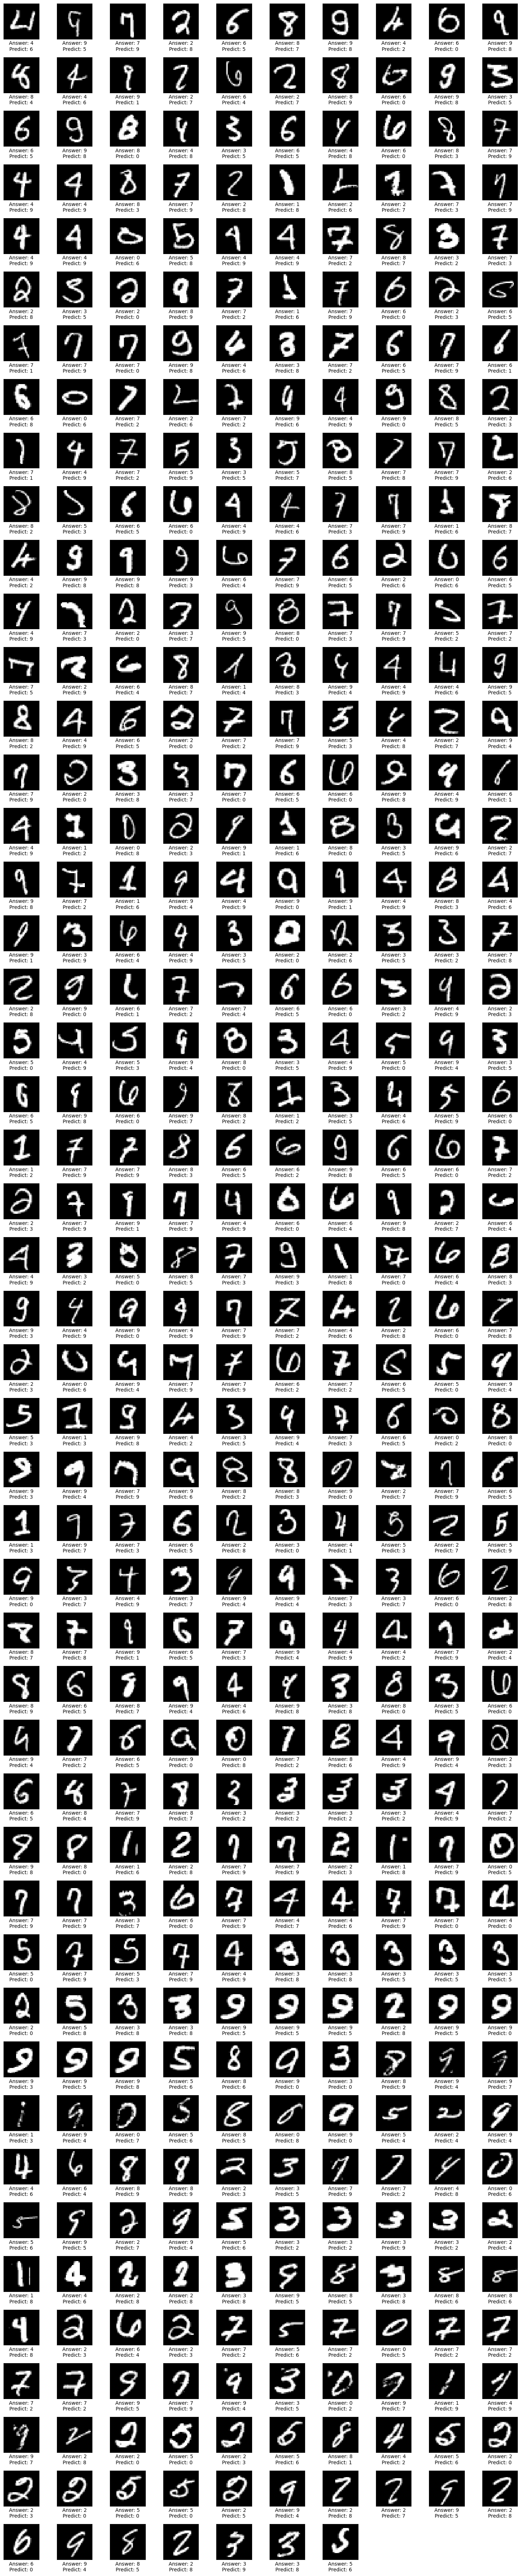

In [35]:
wrongIdx = []

# Find wrong predict indexes
for i in range(len(x_test)):
    predict = np.argmax(result[i])
    answer = np.argmax(y_test[i])
    if predict != answer:
        wrongIdx.append(i)

total_columns = 10

if len(wrongIdx) > 0:
    total_rows = math.ceil(len(wrongIdx) / total_columns)
    plt.figure(figsize=(15, total_rows * 1.5))
    for j in range(len(wrongIdx)):
        plt.subplot(total_rows, total_columns, j + 1)
        plt.imshow(x_test[wrongIdx[j]], cmap='gray')
        plt.xlabel(
            f"Answer: {np.argmax(y_test[wrongIdx[j]])}\n"
            f"Predict: {np.argmax(result[wrongIdx[j]])}"
        )
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout()
    plt.show()
else:
    print("No wrong predictions found.")

In [16]:
y_test[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [1]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
y_pred = np.argmax(result, axis=1)
y_test_int = np.argmax(y_test, axis=1)

In [23]:
cm = confusion_matrix(y_test_int, y_pred, labels=range(10))

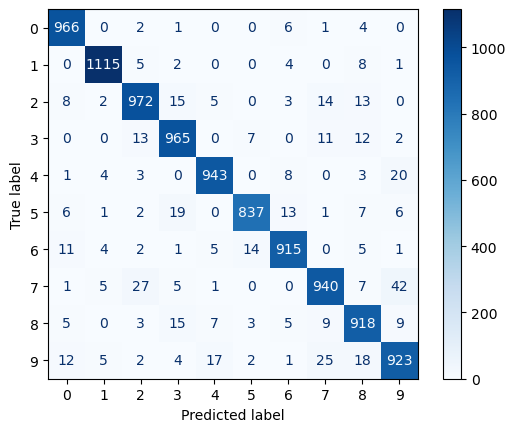

In [24]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap=plt.cm.Blues)
plt.show()